In [ ]:
import numpy as np
import scipy as sp
import pandas as pd
import matplotlib.pyplot as plt
from geomstats.geometry.hypersphere import Hypersphere
import geomstats.visualization as visualization
from numpy.polynomial.legendre import Legendre


sphere = Hypersphere(dim=2)


In [ ]:
plt.rcParams.update({'font.size': 10,
                     'mathtext.fontset': 'stix',
                     'font.family': 'serif',
                     'font.serif':'Palatino'})

# Function to plot spherical coordinates (theta, phi) to Mollweide lon/lat projection
def scatter_mollwide(X_sph, ax, color, alpha=.5, s=5, lw=.5):
    theta = X_sph[:, 0]  # colatitude
    phi = X_sph[:, 1]    # longitude

    # Convert to Mollweide coordinates
    phi_mw = phi - np.pi           # shift longitude from [0, 2π] to [-π, π]
    theta_mw = np.pi/2 - theta     # convert colatitude to latitude [-π/2, π/2]

    # Plot with color parameter
    ax.scatter(phi_mw, theta_mw, s=s, alpha=alpha, color=color)
    ax.grid(True, color='gray', lw=lw)
    return None

In [97]:
# Function to plot spherical coordinates (theta, phi) to Mollweide lon/lat projection
def scatter_mollwide(X_sph, ax, color, alpha=.5, s=5, lw=.5):
    theta = X_sph[:, 0]  # colatitude
    phi = X_sph[:, 1]    # longitude

    # Convert to Mollweide coordinates
    phi_mw = phi - np.pi           # shift longitude from [0, 2π] to [-π, π]
    theta_mw = np.pi/2 - theta     # convert colatitude to latitude [-π/2, π/2]

    # Plot with color parameter
    ax.scatter(phi_mw, theta_mw, s=s, alpha=alpha, color=color)
    ax.grid(True, color='gray', lw=lw)
    return None

In [98]:
def density_estimate(M, X, res_lat=50, res_lon=50):
    """
    Vectorized spherical density estimate using Legendre expansion.
    """
    
    # Grid
    x_lat_ = np.linspace(0, np.pi, res_lat)   # colatitude
    x_lon_ = np.linspace(0, 2*np.pi, res_lon) # longitude
    x_lon, x_lat = np.meshgrid(x_lon_, x_lat_)
    
    # Flatten grids for broadcasting
    theta = x_lat[..., np.newaxis]   # shape (n_lat, n_lon, 1)
    phi = x_lon[..., np.newaxis]     # shape (n_lat, n_lon, 1)

    # Convert grid points to Cartesian coordinates
    grid_x = np.sin(theta) * np.cos(phi)
    grid_y = np.sin(theta) * np.sin(phi)
    grid_z = np.cos(theta)

    grid_points = np.concatenate([grid_x, grid_y, grid_z], axis=-1)
    # shape: (n_lat, n_lon, 3)

    # Compute dot products: (n_lat, n_lon, n_samples)
    dots = np.dot(grid_points, X.T)

    # Initialize output
    hat_f = np.zeros(dots.shape[:2], dtype=np.float64)
    n_samples = X.shape[0]

    # Sum over Legendre polynomials
    for m in range(M):
        p_m = Legendre([0]*m + [1])  # m-th Legendre polynomial
        # Apply polynomial to all dot products and average over samples
        hat_f += (2*m + 1)/(4*np.pi * n_samples) * np.sum(p_m(dots), axis=-1)

    # Fixed gradient computation
    hat_grad_f = np.zeros(shape=(res_lat, res_lon, 3), dtype=np.float64)
    
    for m in range(1, M):
        p_m_deriv = sp.special.legendre(m).deriv()
        # Compute dot products for all grid points and samples
        # dots already computed above has shape (n_lat, n_lon, n_samples)
        
        # Apply derivative: shape (n_lat, n_lon, n_samples)
        p_deriv_values = p_m_deriv(dots)
        
        # For each component of gradient, multiply by corresponding X component
        # and sum over samples
        for d in range(3):
            hat_grad_f[:, :, d] += (2*m + 1)/(4*np.pi * n_samples) * np.sum(
                p_deriv_values * X[:, d], axis=-1
            )
    
    return x_lon, x_lat, hat_f, hat_grad_f

In [141]:

def spherical_kernel_density(X, h=10, res_lat=50, res_lon=50):
    """
    Simple kernel smoothing on S^2 with gradient.
    
    X: (n,3) unit vectors
    h: bandwidth
    """
    n = X.shape[0]
    
    # Grid
    lat = np.linspace(0, np.pi, res_lat)
    lon = np.linspace(0, 2*np.pi, res_lon)
    lon_g, lat_g = np.meshgrid(lon, lat)
    
    # Cartesian grid points
    x = np.stack([
        np.sin(lat_g) * np.cos(lon_g),
        np.sin(lat_g) * np.sin(lon_g),
        np.cos(lat_g)
    ], axis=-1)  # (lat, lon, 3)
    
    # Dot products
    dots = np.tensordot(x, X, axes=([2],[1]))  # (lat, lon, n)
    
    # Gaussian-like kernel on sphere
    K = np.exp((dots - 1)/h**2)
    
    # Density
    f = np.mean(K, axis=-1)
    
    # Euclidean gradient
    grad = np.tensordot(K / h**2, X, axes=([2],[0])) / n  # (lat, lon, 3)
    
    # Tangent space projection
    dot = np.sum(grad * x, axis=-1, keepdims=True)
    grad_tangent = grad - dot * x
    
    return lon_g, lat_g, f, grad_tangent

In [151]:

def denoiser(M, rho, X, sigma2, INTERPOLATE = False):
    # estimate f and its gradient at the sample points X
    # _, _, hat_f, hat_grad_f = density_estimate(M, X)
    _, _, hat_f, hat_grad_f = spherical_kernel_density(X, h=1, res_lat=50, res_lon=50)
    
    # Convert X to spherical coordinates to interpolate density and gradient
    X_sph = sphere.extrinsic_to_spherical(X)
    
    x_lon = X_sph[:, 0]
    x_lat = X_sph[:, 1]
    
    # Need to interpolate hat_f and hat_grad_f from grid to sample points
    # hat_f has shape (res_lat, res_lon)
    # hat_grad_f has shape (res_lat, res_lon, 3)
    # We need values at the sample points X
    
    # Get the grid coordinates from density_estimate
    res_lat, res_lon = hat_f.shape
    lat_grid = np.linspace(0, np.pi, res_lat)
    lon_grid = np.linspace(0, 2*np.pi, res_lon)
    
    if INTERPOLATE :
        # Interpolate density at sample points
        from scipy.interpolate import RegularGridInterpolator
        f_interp = RegularGridInterpolator((lat_grid, lon_grid), hat_f, 
                                            bounds_error=False, fill_value=None)
        hat_f_at_X = f_interp(np.column_stack([x_lat, x_lon]))
        
        # Interpolate gradient at sample points
        hat_score_at_X = np.zeros((X.shape[0], 3))
        for d in range(3):
            grad_interp = RegularGridInterpolator((lat_grid, lon_grid), hat_grad_f[:, :, d],
                                                bounds_error=False, fill_value=None)
            hat_score_at_X[:, d] = grad_interp(np.column_stack([x_lat, x_lon]))
        
        # Compute score function at sample points
        hat_score_at_X = hat_score_at_X / np.maximum(hat_f_at_X, rho).reshape(-1, 1)
    else:
        #  For each sample, find nearest grid indices
        lat_idx = np.abs(lat_grid[:, None] - x_lat[None, :]).argmin(axis=0)
        lon_idx = np.abs(lon_grid[:, None] - x_lon[None, :]).argmin(axis=0)

        hat_f_at_X = hat_f[lat_idx, lon_idx]
        hat_score_at_X = hat_grad_f[lat_idx, lon_idx, :]  # shape (n_samples, 3)
        hat_score_at_X = hat_score_at_X / np.maximum(hat_f_at_X, rho)[:, None]

    # Compute denoiser
    delta = np.zeros((X.shape[0], 3))
    for j in range(X.shape[0]):
        x_ = X[j, :].reshape(-1, 1)
        # Project score onto tangent space at X[j]
        tangent_score = (np.eye(3) - x_ @ x_.T) @ hat_score_at_X[j, :]
        # Exponential map with velocity sigma2 * tangent_score
        delta[j, :] = sphere.metric.exp(sigma2 * tangent_score, X[j, :])
    
    return delta
    

## Setting up

In [143]:

n_samples = 1000
# Generate samples from a mixture of Gaussians on the sphere
_upper = sphere.random_von_mises_fisher(kappa=20, mu=np.array([0, 0, 1]), n_samples=n_samples // 2)
_lower = sphere.random_von_mises_fisher(kappa=20, mu=np.array([0, 0, -1]), n_samples=n_samples // 2)
Theta = np.vstack((_upper, _lower))
# Convert to spherical coordinates
Theta_sph = sphere.extrinsic_to_spherical(Theta)

# Generate samples from a Riemannian normal distribution on the sphere, centered at the Theta
sigma2 = .05
X = sphere.random_riemannian_normal(Theta, 1./np.sqrt(sigma2), n_samples)
X_sph = sphere.extrinsic_to_spherical(X)



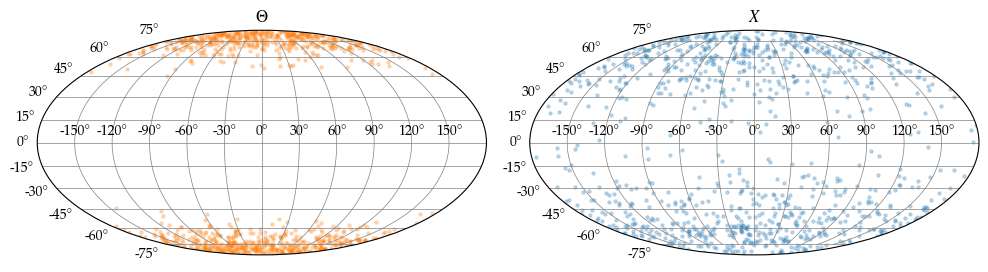

In [144]:
fig, axs = plt.subplots(1, 2, figsize=(10, 4), subplot_kw={'projection': 'mollweide'})

# Left plot: Theta
scatter_mollwide(Theta_sph, axs[0], color='C1', alpha=0.25)
axs[0].set_title('$\\Theta$')

# Right plot: X
scatter_mollwide(X_sph, axs[1], color='C0', alpha=0.25)  # Changed axs[0] to axs[1]
axs[1].set_title('$X$')
plt.tight_layout()
plt.show()

## Density estimation

In [145]:
# Compute density estimate
M = 3
# X_lon_grid, X_lat_grid, hat_f, hat_grad_f = density_estimate( M, X)
X_lon_grid, X_lat_grid, hat_f, hat_grad_f = spherical_kernel_density(X, h=1, res_lat=50, res_lon=50)


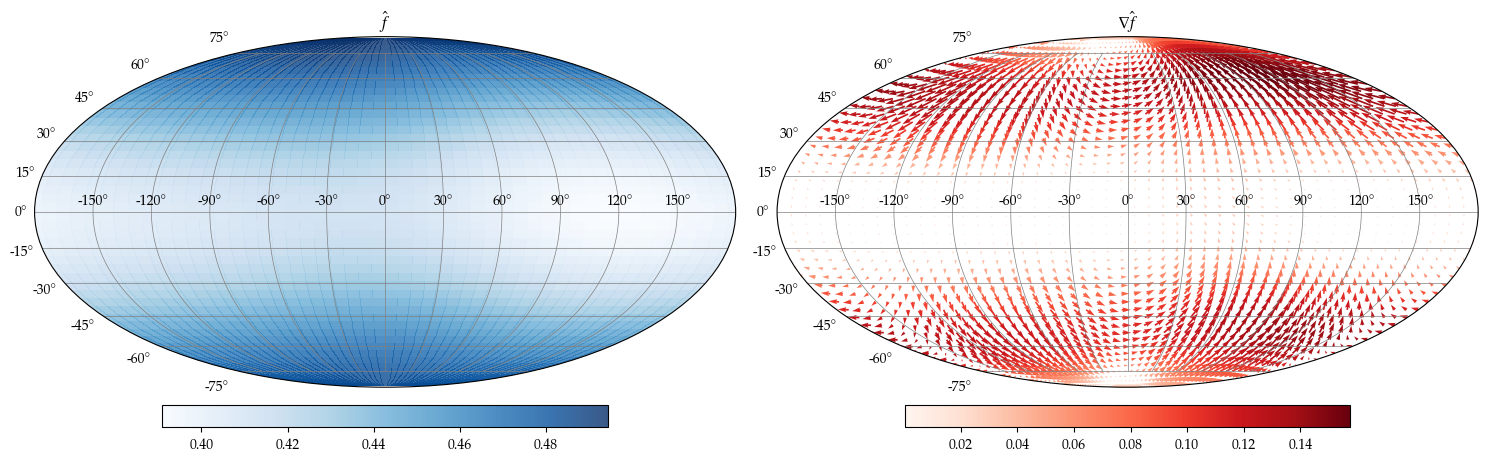

In [146]:
fig, axs = plt.subplots(1, 2, figsize=(15, 5), subplot_kw={'projection': 'mollweide'})

# Middle plot: $\hat{f}$
axs[0].grid(True, color='gray', lw=0.5)
axs[0].set_title('$\\hat{f}$')
X_lon_mw = X_lon_grid - np.pi
X_lat_mw = np.pi / 2 - X_lat_grid
im_f = axs[0].pcolormesh(
    X_lon_mw,
    X_lat_mw,
    hat_f,
    alpha=0.8,
    shading='auto',
    cmap='Blues',
)
fig.colorbar(im_f, ax=axs[0], orientation='horizontal', fraction=0.05, pad=0.04)

# Right plot: $\nabla \\hat{f}$
axs[1].grid(True, color='gray', lw=0.5)
axs[1].set_title('$\\nabla \\hat{f}$')
# step size
eps = 2

# metric correction
cos_lat = np.cos(np.radians(X_lat_mw))

# displacement = moved point − original point
disp_lon = eps * hat_grad_f[:, :, 0] * cos_lat
disp_lat = eps * hat_grad_f[:, :, 1]

# displacement magnitude
magnitude = np.sqrt(disp_lon**2 + disp_lat**2)

# quiver of displacements
im = axs[1].quiver(
    X_lon_mw, X_lat_mw,
    disp_lon, disp_lat,
    magnitude,
    cmap="Reds",
    angles="xy",
    scale_units="xy",
    scale=1
)

fig.colorbar(im, ax=axs[1], orientation="horizontal", fraction=0.05, pad=0.04)
plt.tight_layout()
plt.show()


## Empirical Bayes denoising

In [147]:
rho = 1e-2
# Reshape X_sph[:,0] and X_sph[:,1] to 2D arrays if needed

delta = denoiser(M, rho,X, sigma2)
delta_sph = sphere.extrinsic_to_spherical(delta)

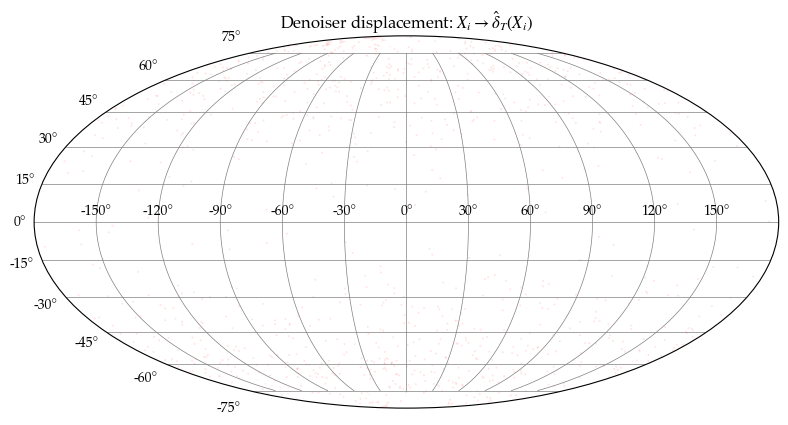

In [148]:
fig, ax = plt.subplots(1, 1, figsize=(8, 8), subplot_kw={'projection': 'mollweide'})

# Compute displacement vectors in spherical coordinates
# Convert to Mollweide coordinates for plotting
X_phi_mw = X_sph[:, 1] - np.pi
X_theta_mw = np.pi/2 - X_sph[:, 0]

delta_phi_mw = delta_sph[:, 1] - np.pi
delta_theta_mw = np.pi/2 - delta_sph[:, 0]

# Compute displacement
u = delta_phi_mw - X_phi_mw
v = delta_theta_mw - X_theta_mw

# Subsample for clearer visualization
stride = 1
ax.quiver(X_phi_mw[::stride], X_theta_mw[::stride], 
          u[::stride], v[::stride], 
          color='red', alpha=100/len(X), scale=5, width=0.003)

ax.grid(True, color='gray', lw=0.5)
ax.set_title('Denoiser displacement: $X_i \\rightarrow \\hat{\\delta}_T(X_i)$')

plt.tight_layout()
plt.show()

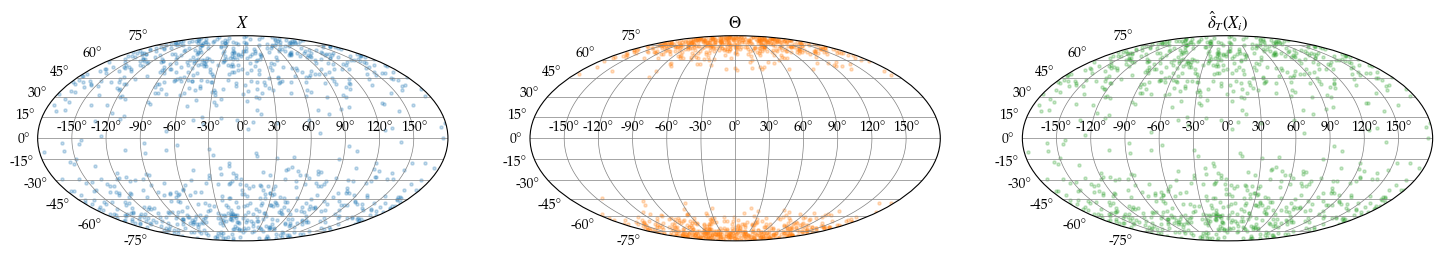

In [149]:
fig, axs = plt.subplots(1, 3, figsize=(18, 8), subplot_kw={'projection': 'mollweide'})
if axs.size == 3: axs = np.array([axs])  # Ensure axs is 2D array

# Top-left plot: X
axs[0,0].grid(True, color='gray', lw=0.5)
axs[0,0].set_title('$X$')
scatter_mollwide(X_sph, ax=axs[0,0], color='C0', alpha=0.25)

# Top-middle plot: Theta
axs[0,1].grid(True, color='gray', lw=0.5)
axs[0,1].set_title('$\\Theta$')
scatter_mollwide(Theta_sph, ax=axs[0,1], color='C1', alpha=0.25)

# Top-right plot: $\hat{\delta}_T(X_i)$
axs[0,2].grid(True, color='gray', lw=0.5)
axs[0,2].set_title('$\\hat{\\delta}_T(X_i)$')
scatter_mollwide(delta_sph, ax=axs[0,2], color='C2', alpha=0.25)




In [150]:
# Compute the mean squared error for the naive estimator (X) using intrinsic metric
mse_naive = np.mean(sphere.metric.dist(X, Theta)**2)**.5

# Compute the mean squared error for the denoised estimator (delta) using intrinsic metric
mse_denoised = np.mean(sphere.metric.dist(delta, Theta)**2)**.5

print(f"Naive Risk: {mse_naive}")
print(f"Denoised Risk: {mse_denoised}")

Naive Risk: 0.6547357968645928
Denoised Risk: 0.6544834615737833
